In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


In [2]:
# loading utility files

from utility.sv_fig import savefig
# from utility.mi_score import MI_score



In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
X_train = pd.read_csv('data/norm_X_train_NCa_PCa.csv')
X_test = pd.read_csv('data/norm_X_test_NCa_PCa.csv')
y_train = pd.read_csv('data/y_train_NCa_PCa.csv')
y_test = pd.read_csv('data/y_test_NCa_PCa.csv')


print(X_train.shape)

(56, 37)


In [4]:
Xy_NCa_PCa = pd.concat([X_train, y_train], axis=1)

In [5]:
# file A
file_A = Xy_NCa_PCa.copy()

In [6]:
#file B

file_B = pd.read_csv('output_NCa_PCa.csv')

In [7]:


# mask of missing values in A
mask = file_A.isna()

# values that were imputed
imputed_values = file_B[mask]

In [8]:
print(file_B.isna().sum())

ENA.78             0
IFN.y              0
IL.10              0
IL.6               0
IL.8               0
MCP.1              0
MDC                0
MIP.1a             0
TNF.a              0
C.peptide          0
G.CSF              0
IL.22              0
Insulin            0
Leptin             0
MIP.3a             0
GRO.a              0
HGF                0
MMP.2              0
Adiponectin        0
CRP                0
GDF.15             0
TIMP.1             0
TGF.B2             0
TGF.B1             0
PPAR.y             0
HIF.1a             0
Laminin            0
HbA1c              0
CA19.9             0
Glucose            0
HDL                0
CCK                0
LDL                0
Triglyceride       0
Albumin            0
Lumican            0
ZAG                0
CACHEXSTAGE0VIG    0
dtype: int64


In [9]:
comparison = []

for col in file_A.columns:
    if file_A[col].isna().sum() > 0:
        original = file_A[col].dropna()
        imputed = file_B[col][mask[col]]
        num_miss = len(imputed)
        print(imputed)
        
        comparison.append({
            'column': col,
            'Training_cohort_mean': original.mean(),
            'Imputed_data_mean': imputed.mean(),
            'Training_cohort_std': original.std(),
            'Imputed_data_std': imputed.std(),
            'Num_of_imputed_data': num_miss
        })

pd.DataFrame(comparison)

18    0.345480
27    0.562648
Name: MIP.1a, dtype: float64
5    0.857937
Name: C.peptide, dtype: float64
2     0.230775
25    0.459974
39    0.103107
43    0.059892
49    0.121621
Name: IL.22, dtype: float64
5    0.553892
Name: Insulin, dtype: float64
6     0.431333
11    0.430339
12    0.438502
13    0.520876
29    0.436216
32    0.370481
33    0.422327
36    0.403708
43    0.479556
Name: MIP.3a, dtype: float64
9     0.647286
10    0.608448
22    0.699466
44    0.524685
46    0.358140
Name: TGF.B2, dtype: float64
0    0.72005
Name: HIF.1a, dtype: float64
7     0.245918
43    0.449160
53    0.650323
Name: CA19.9, dtype: float64
1     0.799707
5     0.815544
6     0.811737
42    0.824009
Name: Triglyceride, dtype: float64
46    0.976387
Name: Albumin, dtype: float64


,column,Training_cohort_mean,Imputed_data_mean,Training_cohort_std,Imputed_data_std,Num_of_imputed_data
0,MIP.1a,0.532516,0.454064,0.107120,0.153561,2
1,C.peptide,0.838580,0.857937,0.061353,NaN,1
2,IL.22,0.361336,0.195074,0.309204,0.160915,5
3,Insulin,0.578695,0.553892,0.152030,NaN,1
4,MIP.3a,0.571928,0.437038,0.137369,0.042828,9
5,TGF.B2,0.709423,0.567605,0.132896,0.133344,5
6,HIF.1a,0.760233,0.720050,0.127993,NaN,1
7,CA19.9,0.499481,0.448467,0.373858,0.202203,3
8,Triglyceride,0.720253,0.812749,0.110635,0.010094,4
9,Albumin,0.978337,0.976387,0.009856,NaN,1


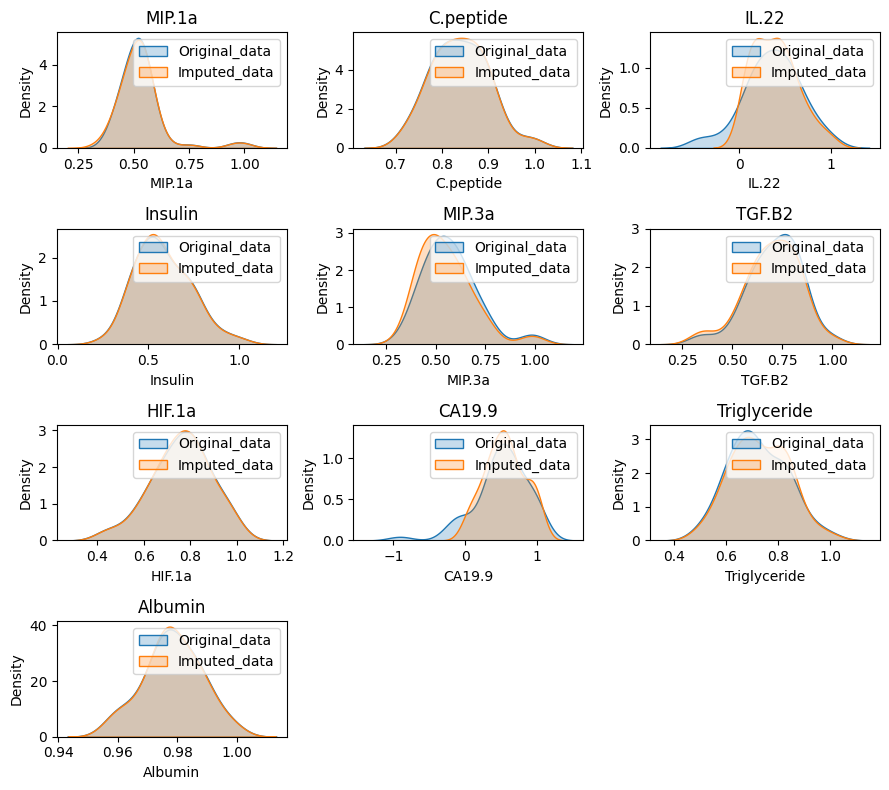

In [10]:
# comparison original vs imputed
import math

cols = ['MIP.1a', 'C.peptide', 'IL.22', 'Insulin', 'MIP.3a', 'TGF.B2', 'HIF.1a', 'CA19.9', 'Triglyceride','Albumin' ]

n_cols = 3  
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(file_A[col], label='Original_data', fill=True, ax=axes[i])
    sns.kdeplot(file_B[col], label='Imputed_data', fill=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].legend()

# remove unused subplots (if any)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
# plt.show()
savefig('./figs/NCa_PCa_den',dpi=600,quality=100)